# 1. Calculate all distances
- pc4 (46,870,226 million edges): 6 seconds

In [1]:
import ibis
import pandas as pd
from utils.f_0_dirs import get_data_dirs
from pathlib import Path

table_in_name = "working_fixed"
table_out_name = "working_distance"
# Limiting group property: any firms that don't share (string match) this variable have null in distance values, i.e. not potential peers.
prop = "pc4"  # 4-digit postcode prefix

# ==========================================
# 1. SETUP & EXTENSION LOADING
# ==========================================
dirs = get_data_dirs()
print("⏳ Initializing DuckDB connection and loading spatial extension...")
start_time = pd.Timestamp.now()

# Assuming dirs.db_path is defined
con = ibis.duckdb.connect(dirs.db_path)
con.raw_sql("INSTALL spatial; LOAD spatial;")

print(f"✅ Database connected in {(pd.Timestamp.now() - start_time).total_seconds():.1f} seconds.\n")

# ==========================================
# 2. THE IBIS ORM PIPELINE (AST Building)
# ==========================================
print("⏳ Building Ibis relational algebra (Lazy Evaluation)...")
ast_start = pd.Timestamp.now()

t = con.table(table_in_name)

# Filter non-nulls and non-zeroes for the relevant columns
t_clean = t.filter([
    t.lon_dec.notnull() & (t.lon_dec != 0),
    t.lat_dec.notnull() & (t.lat_dec != 0),
    t[prop].notnull()
])

# Aliases for the Self-Join
left = t_clean.alias("a")
right = t_clean.alias("b")

# Block-Diagonal Join & Diagonal Filter 
joined = left.join(
    right,
    [
        left[prop] == right[prop],                             # Block-Diagonal
        left.registered_number != right.registered_number  # Exclude self-pairs
    ]
)

# Project the required columns
pairs = joined.select(
    firm_i = left.registered_number,
    firm_j = right.registered_number,
    prop_key = left[prop],
    lon_i = left.lon_dec,
    lat_i = left.lat_dec,
    lon_j = right.lon_dec,
    lat_j = right.lat_dec
)

# Register the Ibis logic as a virtual table (No data processed yet)
con.create_view("temp_spatial_pairs", pairs, overwrite=True)
print(f"✅ Ibis AST built and view registered in {(pd.Timestamp.now() - ast_start).total_seconds():.1f} seconds.\n")

# ==========================================
# 3. RAW SQL SPATIAL WRAPPER & MATERIALIZATION
# ==========================================
print("⏳ Starting out-of-core physical materialization to disk. This may take a minute...")
exec_start = pd.Timestamp.now()

# Apply the ST_Point and ST_Distance_Sphere logic to the Ibis view.
spatial_matrix_expr = con.sql(f"""
    SELECT 
        firm_i,
        firm_j,
        prop_key AS {prop},
        ST_Distance_Sphere(
            ST_Point(lon_i, lat_i), 
            ST_Point(lon_j, lat_j)
        ) AS distance_meters
    FROM temp_spatial_pairs
""")

# Execute the entire unified plan out-of-core
con.create_table(table_out_name, spatial_matrix_expr, overwrite=True)

exec_duration = pd.Timestamp.now() - exec_start
print(f"✅ Materialization complete in {exec_duration.total_seconds():.1f} seconds.\n")

# ==========================================
# 4. VERIFICATION
# ==========================================
print("⏳ Verifying output...")
row_count = con.table(table_out_name).count().execute()

print(f"🎉 SUCCESS! Total edges calculated: {row_count:,}")
print(f"⏱️ Total script execution time: {(pd.Timestamp.now() - start_time).total_seconds():.1f} seconds.\n")

# Optional: Peek at the data
display(con.table(table_out_name).head(5).execute())

⏳ Initializing DuckDB connection and loading spatial extension...
✅ Database connected in 1.5 seconds.

⏳ Building Ibis relational algebra (Lazy Evaluation)...
✅ Ibis AST built and view registered in 0.0 seconds.

⏳ Starting out-of-core physical materialization to disk. This may take a minute...
✅ Materialization complete in 5.6 seconds.

⏳ Verifying output...
🎉 SUCCESS! Total edges calculated: 46,870,226
⏱️ Total script execution time: 7.2 seconds.



,firm_i,firm_j,pc4,distance_meters
0,04706935,02710265,EC1V,376.079585
1,06873977,02710265,EC1V,930.287073
2,03283581,02710265,EC1V,826.365636
3,04330100,02710265,EC1V,812.058728
4,04944709,02710265,EC1V,726.387891


# 2. [read] summary stats: generated distances table

In [32]:
import ibis
from ibis import _
from utils.f_0_dirs import get_data_dirs

table_in_name = "working_fixed"
table_out_name = "working_distance"

dirs = get_data_dirs(segment="descriptives")
con = ibis.duckdb.connect(dirs.db_path)
table_out = con.table(table_out_name)
table_fixed = con.table(table_in_name).select("registered_number", "pc8", "lat_lon5", "address_lvl", "address_case")
tf_i = table_fixed.alias("tf_i")
tf_j = table_fixed.alias("tf_j")

# 3. Perform double left join and explicitly select/rename columns
table_joined = (
    table_out
    .left_join(tf_i, table_out.firm_i == tf_i.registered_number)
    .rename({f"{col}_i": f"{col}" for col in tf_i.columns})
    .left_join(tf_j, table_out.firm_j == tf_j.registered_number)
    .rename({f"{col}_j": f"{col}" for col in tf_j.columns})
)

# Display sample of 500 random rows
table_sample = table_joined.sample(10 / table_joined.count().execute()).execute()
display(table_sample)

# Show largest 50 distances
table_largest = table_joined.order_by(table_joined.distance_meters.desc()).limit(10).execute()
display(table_largest)

,firm_i,firm_j,pc4,distance_meters,registered_number_i,pc8_i,lat_lon5_i,address_lvl_i,address_case_i,registered_number_j,pc8_j,lat_lon5_j,address_lvl_j,address_case_j
0,05073971,00463300,L3,848.601566,05073971,L3 1BG,"53.40911,-3.00044",1,ro,00463300,L3 9LQ,"53.40937,-2.99282",2,pta
1,07181870,02854828,E14,2901.200961,07181870,E14 5NR,"51.50306,-0.01992",1,ro,02854828,E14 0JW,"51.51033,0.00514",1,pta
2,04342994,04016409,M2,419.704826,04342994,M2 6DN,"53.48039,-2.24608",1,ro,04016409,M2 5QR,"53.47825,-2.24919",1,pta
3,07228130,08706238,EC4M,3741.548650,07228130,EC4M 7QS,"51.51764,-0.137",1,pta,08706238,EC4M 7RB,"51.51514,-0.10344",1,ro
4,02388444,01152507,WA14,1208.991839,02388444,WA14 1DU,"53.38594,-2.35044",1,ro,01152507,WA14 1NU,"53.39682,-2.35092",2,pta
5,05170841,01454511,EC4M,104160.604721,05170841,EC4M 7AN,"51.51572,-0.10238",2,ro,01454511,EC4M 7QS,"51.46019,-1.03747",1,pta
6,05046811,04632281,SK9,2074.852489,05046811,SK9 7JP,"53.30811,-2.22667",1,pta,04632281,SK9 1BU,"53.32675,-2.22781",1,pta
7,06194523,07352354,B1,1309.491553,06194523,B1 1TT,"52.47639,-1.90194",1,pta,07352354,B1 2HZ,"52.47778,-1.91364",1,ro
8,05742348,00256111,EC1M,100.609758,05742348,EC1M 6EH,"51.52078,-0.09875",1,pta,00256111,EC1M 6EE,"51.52106,-0.09961",1,pta
9,04908607,03261320,NE1,627.477508,04908607,NE1 5JE,"54.97086,-1.6159",2,ro,03261320,NE1 4EP,"54.96766,-1.62055",2,pta


,firm_i,firm_j,pc4,distance_meters,registered_number_i,pc8_i,lat_lon5_i,address_lvl_i,address_case_i,registered_number_j,pc8_j,lat_lon5_j,address_lvl_j,address_case_j
0,NI037243,04494730,,768851.075890,NI037243,,"55.05914,-6.31494",1,pta,04494730,,"51.37239,-0.46031",1,ro
1,04494730,NI037243,,768851.075890,04494730,,"51.37239,-0.46031",1,ro,NI037243,,"55.05914,-6.31494",1,pta
2,03241146,NI037243,,734991.204212,03241146,,"51.91181,-0.49867",1,pta,NI037243,,"55.05914,-6.31494",1,pta
3,NI037243,03241146,,734991.204212,NI037243,,"55.05914,-6.31494",1,pta,03241146,,"51.91181,-0.49867",1,pta
4,NI008627,NI046813,BT36,717229.700574,NI008627,BT36 4RB,"54.68792,-6.02356",1,pta,NI046813,BT36 4RF,"51.55844,-0.37997",1,pta
5,NI054518,NI053848,BT36,717229.700574,NI054518,BT36 4RE,"51.55844,-0.37997",1,pta,NI053848,BT36 4RE,"54.68792,-6.02356",1,pta
6,NI047139,NI046813,BT36,717229.700574,NI047139,BT36 4RB,"54.68792,-6.02356",1,pta,NI046813,BT36 4RF,"51.55844,-0.37997",1,pta
7,NI053848,NI054518,BT36,717229.700574,NI053848,BT36 4RE,"54.68792,-6.02356",1,pta,NI054518,BT36 4RE,"51.55844,-0.37997",1,pta
8,NI053848,NI046813,BT36,717229.700574,NI053848,BT36 4RE,"54.68792,-6.02356",1,pta,NI046813,BT36 4RF,"51.55844,-0.37997",1,pta
9,NI047139,NI054518,BT36,717229.700574,NI047139,BT36 4RB,"54.68792,-6.02356",1,pta,NI054518,BT36 4RE,"51.55844,-0.37997",1,pta


### range/shape statistics

In [40]:
import ibis

# Assuming connection is still active: con = ibis.duckdb.connect(db_path)
dist_matrix = con.table("working_distance")
working_fixed = con.table("working_fixed")

print("⏳ Calculating summary statistics for 13M rows (Out-of-Core)...")

# 1. Aggregate distance distributions
summary_stats = dist_matrix.aggregate(
    total_edges = dist_matrix.distance_meters.count(),
    min_distance = dist_matrix.distance_meters.min(),
    avg_distance = dist_matrix.distance_meters.mean(),
    median_distance = dist_matrix.distance_meters.approx_median(),
    quantile_95 = dist_matrix.distance_meters.approx_quantile(0.95),
    max_distance = dist_matrix.distance_meters.max()
).execute()

# Print human-readable output
print("\n=== SPATIAL MATRIX HEALTH CHECK ===")
print(f"Total Peer Connections: {summary_stats['total_edges'][0]:,}")
print(f"Minimum Distance:       {summary_stats['min_distance'][0]:,.0f} meters")  # Expect ~0 for firms in same building
print(f"Median Distance:        {summary_stats['median_distance'][0]:,.0f} meters")
print(f"Mean Distance:          {summary_stats['avg_distance'][0]:,.0f} meters")
print(f"95th Percentile Distance: {summary_stats['quantile_95'][0]:,.0f} meters")
print(f"Maximum Distance:       {summary_stats['max_distance'][0]:,.0f} meters")  # Should not exceed UK PC4 bounds (usually < 20km)

# 2. Check for isolated firms (Firms that were the only one in their pc4)
isolated_count = working_fixed.anti_join(dist_matrix, working_fixed.registered_number == dist_matrix.firm_i).count().execute()

print(f"Isolated Firms (0 peers): {isolated_count:,}")

⏳ Calculating summary statistics for 13M rows (Out-of-Core)...

=== SPATIAL MATRIX HEALTH CHECK ===
Total Peer Connections: 46,870,226
Minimum Distance:       0 meters
Median Distance:        728 meters
Mean Distance:          13,120 meters
95th Percentile Distance: 76,349 meters
Maximum Distance:       768,851 meters
Isolated Firms (0 peers): 629


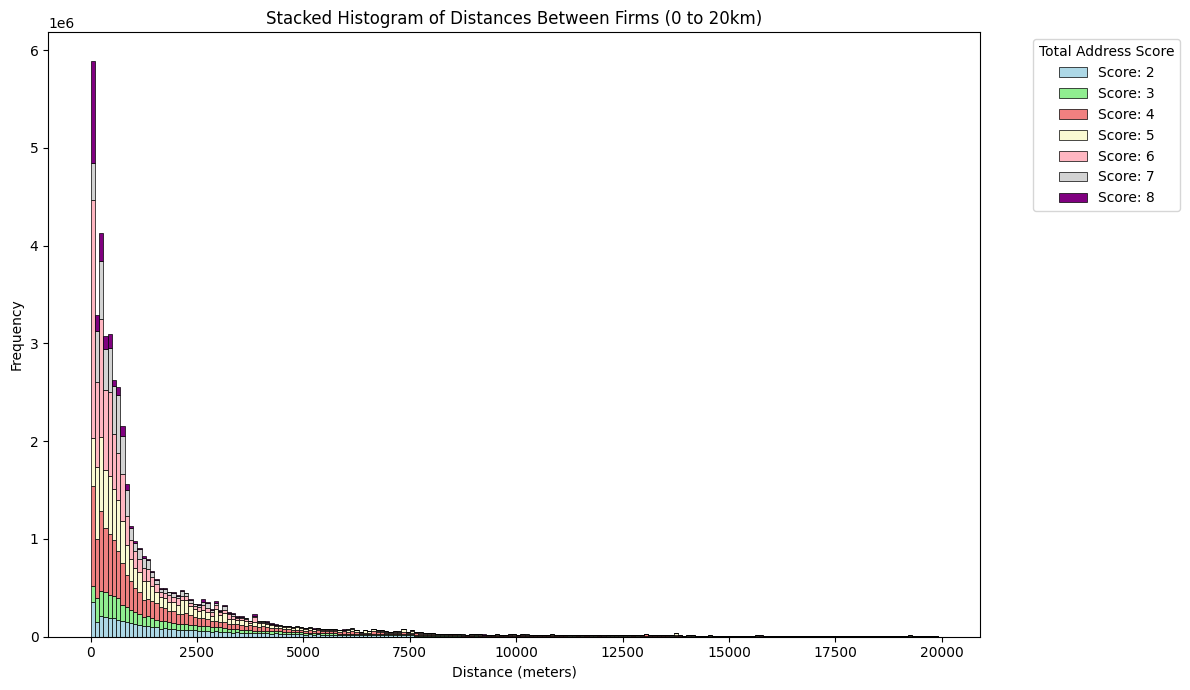

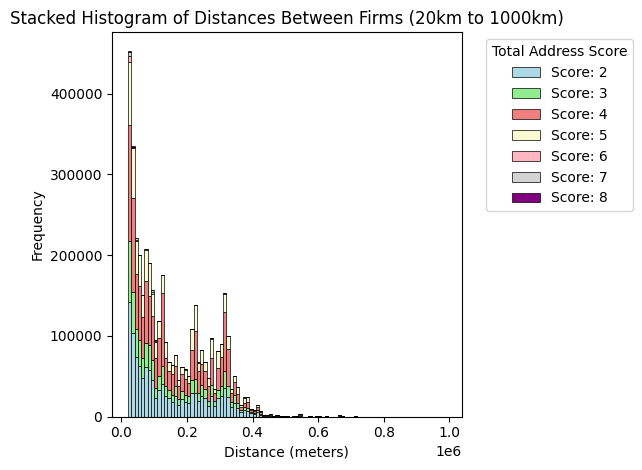

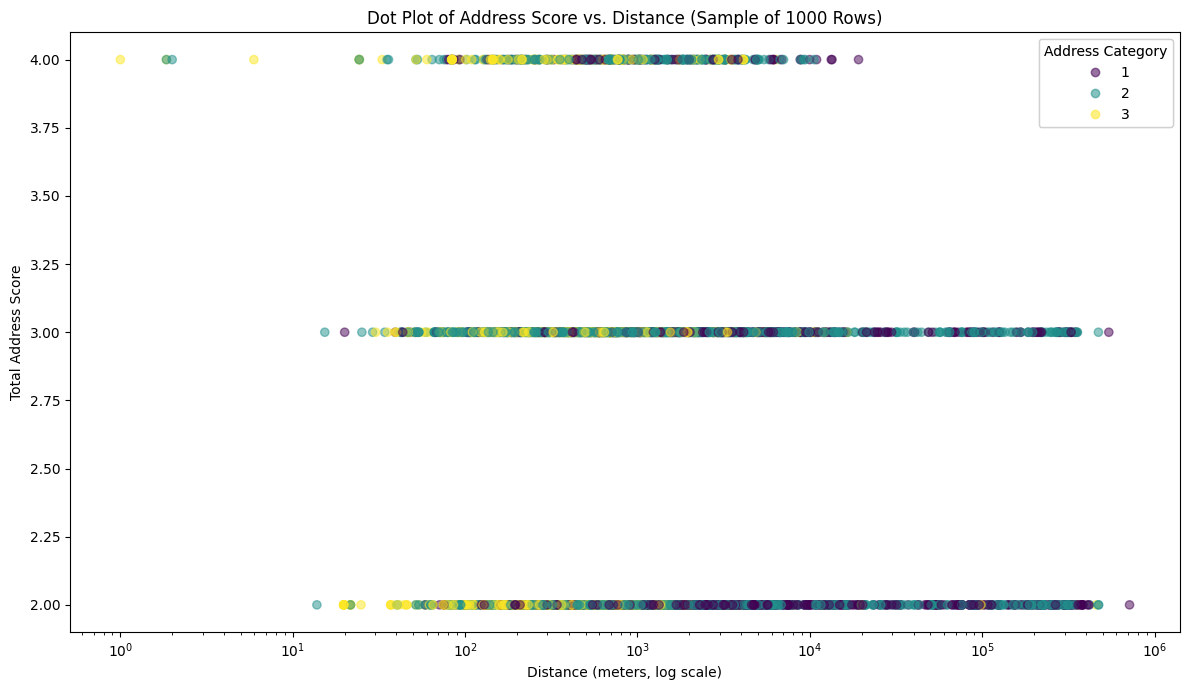

In [34]:
import matplotlib.pyplot as plt
import numpy as np
from ibis import _

cut_off = 20000

# 1. Execute the query and return the FULL DataFrame (both columns)
table_distances = (
    table_joined
    .select(["distance_meters", "address_lvl_i", "address_case_i", "address_lvl_j", "address_case_j"])
    .mutate(
        # Note: Casting the boolean to an integer ensures the multiplication works safely across SQL backends
        address_score_i = _.address_lvl_i + (_.address_case_i == 'ro').cast('int8') * 2,
        address_score_j = _.address_lvl_j + (_.address_case_j == 'ro').cast('int8') * 2,
    )
    .mutate(
        address_score_total = _.address_score_i + _.address_score_j
    )
    .filter(_.address_score_total.notnull())
)
df_distances = (
    table_distances
    .select(["distance_meters", "address_score_total"])
    .execute()
)

# 2. Group the distances by their total score into a list of arrays
# Matplotlib requires the shape: [array(score_1_distances), array(score_2_distances), ...]
unique_scores = sorted(df_distances['address_score_total'].unique())
data_to_plot = [
    df_distances[df_distances['address_score_total'] == score]['distance_meters'].values 
    for score in unique_scores
]

# Create labels mapping to each array for the legend
labels = [f"Score: {int(score)}" for score in unique_scores]

color_map = [
    'lightblue', 'lightgreen', 'lightcoral', 'lightgoldenrodyellow', 'lightpink', 'lightgray',
    'purple', 'orange', 'cyan', 'magenta', 'yellow', 'brown', 'teal', 'navy', 'olive'
]

# 3. Plot the stacked histogram
plt.figure(figsize=(12, 7))

# Pass the list of arrays, set stacked=True
plt.hist(
    data_to_plot, 
    bins=np.arange(0, cut_off, 100), 
    stacked=True, 
    color=color_map[:len(unique_scores)], 
    label=labels,
    edgecolor='black',
    linewidth=0.5
)
plt.title(f'Stacked Histogram of Distances Between Firms (0 to {cut_off/1000:.0f}km)')
plt.xlabel('Distance (meters)')
plt.ylabel('Frequency')
plt.legend(title='Total Address Score', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() # Ensures the external legend isn't cut off
plt.show()

# Pass the list of arrays, set stacked=True
plt.hist(
    data_to_plot, 
    bins=np.arange(cut_off, 1000000, 10000), 
    stacked=True, 
    color=color_map[:len(unique_scores)], 
    label=labels,
    edgecolor='black',
    linewidth=0.5
)
plt.title(f'Stacked Histogram of Distances Between Firms ({cut_off/1000:.0f}km to 1000km)')
plt.xlabel('Distance (meters)')
plt.ylabel('Frequency')
plt.legend(title='Total Address Score', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() # Ensures the external legend isn't cut off
plt.show()

# Take a sample of 1000 rows
# Plot a dot plot with address_score on the y-axis and distance_meters on the x-axis.
# Use a log scale for the x-axis to better visualize the distribution of distances.
# Sample unique_scores for 1000 rows
# address_category is 1 if both are 'pta', 2 if one is 'pta' and the other is 'ro', and 3 if both are 'ro'
df_sample = (
    table_distances
    .mutate(
        address_score = table_distances.address_lvl_i + table_distances.address_lvl_j,
        address_cat=ibis.cases(
            ((table_distances.address_case_i == 'pta') & (table_distances.address_case_j == 'pta'), 1),
            ((table_distances.address_case_i == 'ro') & (table_distances.address_case_j == 'ro'), 3),
            else_=2
        )
    )
    .sample(0.0001)
    .execute()
)
# Plot a dot plot with address_score on the y-axis and distance_meters on the x-axis.
# Use address_cat to denote series
plt.figure(figsize=(12, 7))
scatter = plt.scatter(
    df_sample['distance_meters'], 
    df_sample['address_score'], 
    c=df_sample['address_cat'], 
    cmap='viridis', 
    alpha=0.5
)
plt.xscale('log')
plt.title('Dot Plot of Address Score vs. Distance (Sample of 1000 Rows)')
plt.xlabel('Distance (meters, log scale)')
plt.ylabel('Total Address Score')
legend1 = plt.legend(*scatter.legend_elements(), title="Address Category")
plt.gca().add_artist(legend1)
plt.tight_layout()
plt.show()


In [59]:
out_table_name_2 = "working_distance_filtered"

# Drop all distances which are larger than 20km.
# These will have a very weak effect in the regresssion anyway since we use a distance decay function.
filtered_matrix = dist_matrix.filter(dist_matrix.distance_meters <= 20000)

con.create_table(out_table_name_2, filtered_matrix, overwrite=True)
filtered_matrix = con.table(out_table_name_2)

print(f"⏳ Calculating summary statistics for {filtered_matrix.count().execute():,} rows (Out-of-Core)...")

# 1. Aggregate distance distributions
summary_stats = filtered_matrix.aggregate(
    total_edges = filtered_matrix.distance_meters.count(),
    min_distance = filtered_matrix.distance_meters.min(),
    avg_distance = filtered_matrix.distance_meters.mean(),
    median_distance = filtered_matrix.distance_meters.approx_median(),
    quantile_95 = filtered_matrix.distance_meters.approx_quantile(0.95),
    max_distance = filtered_matrix.distance_meters.max()
).execute()

# Print human-readable output
print("\n=== SPATIAL MATRIX HEALTH CHECK ===")
print(f"Total Peer Connections: {summary_stats['total_edges'][0]:,}")
print(f"Minimum Distance:       {summary_stats['min_distance'][0]:,.0f} meters")  # Expect ~0 for firms in same building
print(f"Median Distance:        {summary_stats['median_distance'][0]:,.0f} meters")
print(f"Mean Distance:          {summary_stats['avg_distance'][0]:,.0f} meters")
print(f"95th Percentile Distance: {summary_stats['quantile_95'][0]:,.0f} meters")
print(f"Maximum Distance:       {summary_stats['max_distance'][0]:,.0f} meters")  # Should not exceed UK PC4 bounds (usually < 20km)

# 2. Check for isolated firms (Firms that were the only one in their pc4)
isolated_count = working_fixed.anti_join(filtered_matrix, working_fixed.registered_number == filtered_matrix.firm_i).count().execute()

print(f"Isolated Firms (0 peers): {isolated_count:,}")

⏳ Calculating summary statistics for 43,241,404 rows (Out-of-Core)...

=== SPATIAL MATRIX HEALTH CHECK ===
Total Peer Connections: 43,241,404
Minimum Distance:       0 meters
Median Distance:        656 meters
Mean Distance:          1,625 meters
95th Percentile Distance: 6,775 meters
Maximum Distance:       20,000 meters
Isolated Firms (0 peers): 3,365


In [60]:
# ==========================================
# CELL 2: SINGLE FIRM "EGO-NETWORK" PREVIEW (PURE IBIS)
# ==========================================
# Assume connections exist
working_fixed = con.table("working_fixed")
dist_matrix = con.table("working_distance_filtered")

# 1. Pick a random firm that has a decent number of peers (20 to 50)
target_firm_expr = (
    dist_matrix
    .group_by(['firm_i', 'pc4'])
    .agg(peer_count=dist_matrix.firm_j.count())
    .filter(lambda t: (t.peer_count >= 20) & (t.peer_count <= 50))
    .limit(1)
)

target_info = target_firm_expr.execute()
target_firm_id = target_info['firm_i'].iloc[0]
target_pc4 = target_info['pc4'].iloc[0]

print(f"Examining Firm: {target_firm_id} (Postcode Sector: {target_pc4})")
print(f"Total peers in sector: {target_info['peer_count'].iloc[0]}")

# 2. Pull this specific firm's network using Ibis Joins
# First, filter the 13M row matrix down to just the ~30 rows for our target firm
ego_edges = dist_matrix.filter(dist_matrix.firm_i == target_firm_id)

# Setup aliases so we can join the working_fixed table to itself twice
w1 = working_fixed.alias("w1") # For the Target Firm's coordinates

Examining Firm: 06347827 (Postcode Sector: EC2A)
Total peers in sector: 23


In [61]:
# ==========================================
# CELL 3: INTERACTIVE NETWORK MAPPING (MODULAR & ORM)
# ==========================================
import ibis
import pandas as pd
import folium

# --- USER VARIABLES ---
sample_nb_firms = 10
include_firms = ["03140144"]
exclude_london = True

# ==========================================
# 1. REUSABLE DATA FETCHING FUNCTION
# ==========================================
# Joins the fixed and distance tables
def get_ego_networks(firm_ids: list, table_full_out: ibis.Table, self_table_fixed: ibis.Table) -> pd.DataFrame:
    tf_i = self_table_fixed.alias("tf_i").rename("{name}_i")
    tf_j = self_table_fixed.alias("tf_j").rename("{name}_j")

    # Filter the massive distance matrix down to just our target firms
    if len(firm_ids) <= 40:
        table_out = table_full_out.filter(table_full_out.firm_i.isin(firm_ids))
    else:
        # If the list is too long, we can use a memtable and inner_join
        temp_table = ibis.memtable({"firm_id": firm_ids})
        table_out = (
            table_full_out.inner_join(temp_table, table_full_out.firm_i == temp_table.firm_id)
            .select(table_full_out.columns)
        )

    network_expr = (
        table_out
        .left_join(tf_i, table_out.firm_i == tf_i.registered_number_i)
        .left_join(tf_j, table_out.firm_j == tf_j.registered_number_j)
        .rename(
            target_firm = "firm_i",
            peer_firm = "firm_j",
            target_lat = "lat_dec_i",
            target_lon = "lon_dec_i",
            target_pc8 = "pc8_i",
            peer_lat = "lat_dec_j",
            peer_lon = "lon_dec_j",
            peer_pc8 = "pc8_j",
        )
        .order_by("distance_meters")
    )
    
    return network_expr.execute()

# ==========================================
# 2. REUSABLE PLOTTING FUNCTION
# ==========================================
# Generates a Folium map plotting multiple firm networks in unique colors.
def plot_ego_networks(df_networks: pd.DataFrame) -> folium.Map:
    if df_networks.empty:
        print("No network data found to plot.")
        return None

    # Center map on the average coordinates of all targets
    center_lat = df_networks['target_lat'].mean()
    center_lon = df_networks['target_lon'].mean()
    m = folium.Map(location=[center_lat, center_lon], zoom_start=11, tiles="CartoDB positron")

    unique_targets = df_networks['target_firm'].unique()
    
    # A palette of distinct Folium-supported colors
    colors = [
        'red', 'blue', 'green', 'purple', 'orange', 
        'darkred', 'cadetblue', 'darkgreen', 'darkpurple', 'black'
    ]

    for idx, target_id in enumerate(unique_targets):
        color = colors[idx % len(colors)]
        target_data = df_networks[df_networks['target_firm'] == target_id]

        t_lat = target_data['target_lat'].iloc[0]
        t_lon = target_data['target_lon'].iloc[0]
        t_pc8 = target_data['target_pc8'].iloc[0]

        # Add Target Firm Marker (Star)
        folium.Marker(
            location=[t_lat, t_lon],
            tooltip=(
                "<b>TARGET FIRM</b>" +
                "<br>".join(": ".join([k, str(v)]) for k, v in {
                    "ID": target_id,
                    "Postcode": t_pc8
                }.items())
            ),
            icon=folium.Icon(color=color, icon="star")
        ).add_to(m)

        max_dist = target_data['distance_meters'].max() or 1 

        # Add Peers and Edges
        for _, row in target_data.iterrows():
            p_lat = row['peer_lat']
            p_lon = row['peer_lon']
            p_pc8 = row['peer_pc8']
            dist = row['distance_meters']
            peer_id = row['peer_firm']
            
            # Peer Marker
            folium.CircleMarker(
                location=[p_lat, p_lon],
                radius=4,
                color=color,
                fill=True,
                fill_color=color,
                fill_opacity=0.6,
                tooltip="<br>".join(": ".join([k, str(v)]) for k, v in {
                    "Peer": peer_id,
                    "Postcode": p_pc8,
                    "Distance": f"{dist:,.1f} m"
                }.items())
            ).add_to(m)
            
            # Spatial Edge (Fades out over distance)
            opacity = max(0.1, 1.0 - (dist / max_dist))
            folium.PolyLine(
                locations=[(t_lat, t_lon), (p_lat, p_lon)],
                color=color,
                weight=1.5,
                opacity=opacity,
                dash_array="5, 5"
            ).add_to(m)

    return m

# ==========================================
# 3. EXECUTION: SAMPLE AND VISUALIZE
# ==========================================
print(f"⏳ Sampling {sample_nb_firms} firms and generating networks...")

working_fixed_skinny = working_fixed.select("registered_number", "ttwa", "pc8", "lat_dec", "lon_dec")
# ref_ttwa = con.table("ttwa")
ref_ttwa = con.read_csv(dirs.input_dir / "TTWA Travel to Work Area names and codes UK as at 12_11 v5.csv")

# 3a. Create an aggregated view of firms and their peer counts (no maximum bound)
target_firm_expr = (
    dist_matrix
    .group_by('firm_i')
    .agg(peer_count=dist_matrix.firm_j.count())
    .filter(lambda t: t.peer_count >= 10)  # Just ensuring they aren't isolated
)

# 3b. Get row count to calculate the exact sample fraction Ibis needs
row_count = target_firm_expr.count().execute()

# 3c. Sample the IDs. (We add .limit() because .sample() is approximate and might return 6)

if exclude_london:
    sampled_targets_filtered = (
        target_firm_expr
        .inner_join(working_fixed_skinny, target_firm_expr.firm_i == working_fixed_skinny.registered_number)
        .inner_join(ref_ttwa, ibis._.ttwa == ref_ttwa.TTWA11CD)
        .filter(ibis._.TTWA11NM != 'London')
    )
else:
    sampled_targets_filtered = target_firm_expr
row_count = sampled_targets_filtered.count().execute()
sample_targets_df = (
    sampled_targets_filtered
    .sample(sample_nb_firms / row_count)
    .limit(sample_nb_firms)
    .select(target_firm_expr.columns)
)
if include_firms:
    include_expr = target_firm_expr.filter(target_firm_expr.firm_i.isin(include_firms))
    sampled_targets_df = sampled_targets_df.union(include_expr).distinct()

sampled_targets_hydrated = (
    sampled_targets_df
    .inner_join(working_fixed_skinny, sampled_targets_df.firm_i == working_fixed_skinny.registered_number)
    .inner_join(ref_ttwa, ibis._.ttwa == ref_ttwa.TTWA11CD)
    .execute()
)

target_ids = sampled_targets_hydrated['firm_i'].tolist()
print(f"🎯 Selected Target Firms: {target_ids}")

# 3d. Fetch data using our reusable function
df_multi_network = get_ego_networks(target_ids, dist_matrix, working_fixed_skinny)
# For every row in hydrated, print its ttwa and number of peers fetched
for row in sampled_targets_hydrated.itertuples():
    target_id = row.firm_i
    peer_count = len(df_multi_network[df_multi_network['target_firm'] == target_id])
    print(f"✅ Fetched {peer_count} edges for target firm {target_id} in {row.TTWA11NM}.")

# 3e. Generate and display the map using our reusable function
network_map = plot_ego_networks(df_multi_network)

# Display network_map in out_dir as an html
out_path = dirs.output_dir / "ego_network_map.html"
print(f"⏳ Saving ego-network map to {out_path}")
network_map.save(out_path)

⏳ Sampling 10 firms and generating networks...
🎯 Selected Target Firms: ['03263721', '12590994', '00933463', '02476571', '04839785', 'SC267156', '00494988', '03140144', '03140144', '07785001', '03917262']
✅ Fetched 40 edges for target firm 03263721 in Grimsby.
✅ Fetched 179 edges for target firm 12590994 in Bristol.
✅ Fetched 36 edges for target firm 00933463 in Birmingham.
✅ Fetched 51 edges for target firm 02476571 in Birmingham.
✅ Fetched 33 edges for target firm 04839785 in Trowbridge.
✅ Fetched 75 edges for target firm SC267156 in Aberdeen.
✅ Fetched 1137 edges for target firm 00494988 in Manchester.
✅ Fetched 69 edges for target firm 03140144 in London.
✅ Fetched 69 edges for target firm 03140144 in London.
✅ Fetched 88 edges for target firm 07785001 in Reading.
✅ Fetched 108 edges for target firm 03917262 in Cambridge.
⏳ Saving ego-network map to C:\Users\lazyst\Files\ucl\Dissertation\descriptives\output\ego_network_map.html


In [ ]:
con.raw_sql("CHECKPOINT;")
con.disconnect()